# Домашнє завдання. Логістична регресія. Оцінка якості класифікації

## 1. Імпорт необхідних пакетів

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_columns', None)

## 2. Завантаження набору даних Rain in Australia

Завантажуємо набір «Rain in Australia» (`weatherAUS.csv`) напряму з GitHub за
raw-посиланням, тож ноутбук працює будь-де без локальної копії файлу. Цільова ознака —
`RainTomorrow` (чи буде завтра дощ, «Yes»/«No»), тож перед нами задача **бінарної
класифікації**.

In [2]:
url = 'https://raw.githubusercontent.com/valeriandema/ml_basics/main/weatherAUS.csv'
data = pd.read_csv(url)
data.shape

(145460, 23)

In [3]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 3. Обробка часових ознак і підготовка даних

### 3.1. Видалення ознак з великою кількістю пропущених значень

Дивимось на частку пропусків по колонках.

In [4]:
data.isna().mean().sort_values(ascending=False)

Sunshine         0.480098
Evaporation      0.431665
Cloud3pm         0.408071
Cloud9am         0.384216
Pressure9am      0.103568
Pressure3pm      0.103314
WindDir9am       0.072639
WindGustDir      0.070989
WindGustSpeed    0.070555
Humidity3pm      0.030984
WindDir3pm       0.029066
Temp3pm          0.024811
RainTomorrow     0.022460
Rainfall         0.022419
RainToday        0.022419
WindSpeed3pm     0.021050
Humidity9am      0.018246
WindSpeed9am     0.012148
Temp9am          0.012148
MinTemp          0.010209
MaxTemp          0.008669
Date             0.000000
Location         0.000000
dtype: float64

Колонки `Sunshine`, `Evaporation`, `Cloud3pm`, `Cloud9am` мають ~40–50% пропусків.
Залишаємо лише ознаки, де пропущено менше 35% значень, і прибираємо рядки без
цільової змінної.

In [5]:
data = data[data.columns[data.isna().mean().lt(0.35)]]
data = data.dropna(subset='RainTomorrow')
data.shape

(142193, 19)

### 3.2. Підмножини набору з числовими та категоріальними ознаками

In [6]:
data_num = data.select_dtypes(include=np.number).copy()
data_cat = data.select_dtypes(include='object').copy()

print('Числові:     ', list(data_num.columns))
print('Категоріальні:', list(data_cat.columns))

Числові:      ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
Категоріальні: ['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']


### 3.3. Перетворення Date у тип datetime і створення колонок Year та Month

Із дати виділяємо рік і місяць. Спершу додаємо їх до підмножини категоріальних ознак.

In [7]:
data_cat['Date'] = pd.to_datetime(data['Date'])
data_cat[['Year', 'Month']] = data_cat['Date'].apply(lambda x: pd.Series([x.year, x.month]))
data_cat.drop('Date', axis=1, inplace=True)
data_cat[['Year', 'Month']] = data_cat[['Year', 'Month']].astype(str)
data_cat[['Year', 'Month']].head()

,Year,Month
0,2008,12
1,2008,12
2,2008,12
3,2008,12
4,2008,12


### 3.4. Перенесення колонки Year до числових ознак

Надалі **«рік» обробляємо як числову ознаку**, а **«місяць» року — як категоріальну**
(це радше 12 окремих категорій, аніж число, де грудень «більший» за січень).
Тому переносимо `Year` з підмножини категоріальних ознак до підмножини числових,
а `Month` лишаємо серед категоріальних.

In [8]:
data_num['Year'] = data_cat['Year'].astype(int)
data_cat.drop('Year', axis=1, inplace=True)

print('Числові:     ', list(data_num.columns))
print('Категоріальні:', list(data_cat.columns))

Числові:      ['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm', 'Year']
Категоріальні: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow', 'Month']


## 4. Розбиття на навчальну і тестову вибірки

У наборі є час, тож звичайне випадкове розбиття некоректне — у навчальну вибірку
могли б потрапити «майбутні» спостереження, і виник би витік даних. Тому робимо
**коректне часове розбиття**: останній наявний у даних рік визначаємо програмно
(`year.max()`) і відкладаємо його на тест, а всі попередні роки лишаємо на навчання.
Такий підхід чесніше моделює реальну ситуацію «навчаємось на минулому, прогнозуємо
майбутнє».

In [9]:
year = pd.to_datetime(data['Date']).dt.year
max_year = year.max()
train_mask = year < max_year
test_mask = year == max_year

X_train_num, X_test_num = data_num[train_mask], data_num[test_mask]
X_train_cat, X_test_cat = (data_cat.drop('RainTomorrow', axis=1)[train_mask],
                           data_cat.drop('RainTomorrow', axis=1)[test_mask])
y_train, y_test = data['RainTomorrow'][train_mask], data['RainTomorrow'][test_mask]

print('останній рік (тест):', max_year)
print('train:', X_train_num.shape[0], '| test:', X_test_num.shape[0])

останній рік (тест): 2017
train: 133727 | test: 8466


## 5. Відновлення пропущених даних і нормалізація числових ознак

Пропуски у числових ознаках заповнюємо середнім (`SimpleImputer` за замовчуванням),
у категоріальних — найчастішим значенням. Числові ознаки нормалізуємо `StandardScaler`.
Усі перетворювачі навчаємо **лише на тренувальній вибірці**, а до тестової застосовуємо
готові параметри — щоб уникнути витоку даних.

In [10]:
num_imputer = SimpleImputer().set_output(transform='pandas')
X_train_num = num_imputer.fit_transform(X_train_num)
X_test_num = num_imputer.transform(X_test_num)

cat_imputer = SimpleImputer(strategy='most_frequent').set_output(transform='pandas')
X_train_cat = cat_imputer.fit_transform(X_train_cat)
X_test_cat = cat_imputer.transform(X_test_cat)

In [11]:
scaler = StandardScaler().set_output(transform='pandas')
X_train_num = scaler.fit_transform(X_train_num)
X_test_num = scaler.transform(X_test_num)
X_train_num.describe().loc[['mean', 'std']]

,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,Year
mean,-2.584429e-16,1.020169e-16,1.764043e-17,4.152940e-16,-7.226201e-18,4.199698e-16,-4.896814e-16,-4.216701e-16,2.117192e-14,3.183099e-14,1.088181e-16,6.053006e-16,-8.630634e-15
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00


## 6. Кодування категоріальних ознак і об'єднання підмножин

Кодуємо категоріальні ознаки методом One-Hot (`drop='if_binary'` — для бінарних
колонок на кшталт `RainToday` лишаємо одну колонку). Далі об'єднуємо числову
(нормалізовану) та категоріальну (закодовану) підмножини в єдині матриці ознак.

In [12]:
encoder = OneHotEncoder(drop='if_binary', sparse_output=False,
                        handle_unknown='ignore').set_output(transform='pandas')
X_train_cat = encoder.fit_transform(X_train_cat)
X_test_cat = encoder.transform(X_test_cat)
X_train_cat.shape

(133727, 110)

In [13]:
X_train = pd.concat([X_train_num, X_train_cat], axis=1)
X_test = pd.concat([X_test_num, X_test_cat], axis=1)
X_train.shape

(133727, 123)

## 7. Побудова моделі

Спершу подивимось на баланс класів у навчальній вибірці.

In [14]:
y_train.value_counts(normalize=True)

RainTomorrow
No     0.77481
Yes    0.22519
Name: proportion, dtype: float64

Класи незбалансовані (≈78% «No» проти ≈22% «Yes»), тому задаємо
`class_weight='balanced'` — модель отримує більшу вагу за помилки на рідшому класі «Yes».

In [15]:
clf = LogisticRegression(solver='liblinear', class_weight='balanced',
                         random_state=42).fit(X_train, y_train)
pred = clf.predict(X_test)

## 8. Оцінка показників моделі

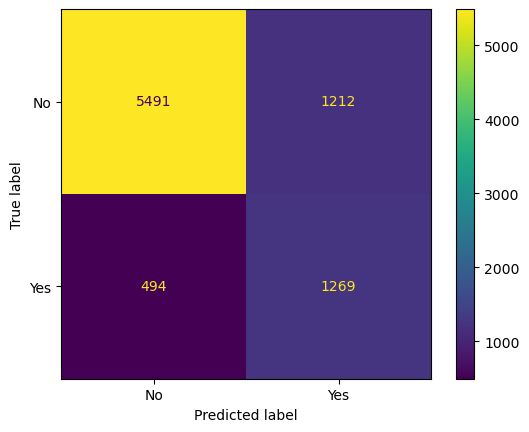

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, pred)
plt.show()

In [17]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

          No       0.92      0.82      0.87      6703
         Yes       0.51      0.72      0.60      1763

    accuracy                           0.80      8466
   macro avg       0.71      0.77      0.73      8466
weighted avg       0.83      0.80      0.81      8466



## 9. Порівняння з базовою моделлю та висновки

Порівняємо нашу зважену модель із **базовою моделлю** — звичайною логістичною регресією
з типовими налаштуваннями (без `class_weight`). Так видно, що саме дає врахування
дисбалансу класів. Дані, розбиття та ознаки — ті самі.

In [18]:
clf_base = LogisticRegression(solver='liblinear', random_state=42).fit(X_train, y_train)
base_pred = clf_base.predict(X_test)
print(classification_report(y_test, base_pred))

              precision    recall  f1-score   support

          No       0.87      0.95      0.91      6703
         Yes       0.71      0.44      0.55      1763

    accuracy                           0.85      8466
   macro avg       0.79      0.70      0.73      8466
weighted avg       0.84      0.85      0.83      8466



In [19]:
our = classification_report(y_test, pred, output_dict=True)
base = classification_report(y_test, base_pred, output_dict=True)

comparison = pd.DataFrame(
    {
        'Базова модель (без зважування)': [
            round(base['accuracy'], 2),
            round(base['Yes']['recall'], 2),
            round(base['macro avg']['f1-score'], 2),
        ],
        'Наша модель (class_weight=balanced)': [
            round(our['accuracy'], 2),
            round(our['Yes']['recall'], 2),
            round(our['macro avg']['f1-score'], 2),
        ],
    },
    index=['accuracy', 'recall (Yes)', 'macro avg f1'],
)
comparison

,Базова модель (без зважування),Наша модель (class_weight=balanced)
accuracy,0.85,0.80
recall (Yes),0.44,0.72
macro avg f1,0.73,0.73


### Висновки

* **Розбиття даних коректне.** Тестова вибірка (останній наявний рік — 2017) містить
  `No` — 6703, `Yes` — 1763, разом — **8466** спостережень.
* **Базова модель без зважування дає вищу загальну accuracy (≈0.85)**, але recall для
  класу «Yes» у неї лише ≈0.44 — вона «перестраховується» у бік частішого «No» і
  пропускає багато реальних дощових днів.
* **Наша зважена модель має accuracy ≈0.80**, зате ловить рідший клас значно краще
  (recall для «Yes» ≈0.72) і має вищий `macro avg f1`. Тобто вища accuracy базової
  моделі оманлива: за незбалансованих класів важливіше дивитись на recall/f1 для
  рідшого класу.
* Клас «No» в обох моделях прогнозується впевнено.

Вибір між моделями залежить від задачі: якщо ціна пропущеного дощу висока, доцільніша
зважена модель. Отримані результати підтверджують коректність усього ланцюжка підготовки
даних: видалення ознак з великою кількістю пропусків, коректне **часове** розбиття на
вибірки, відновлення пропусків та нормалізація тільки за статистиками train, роздільна
обробка `Year` (числова) і `Month` (категоріальна) та One-Hot кодування категоріальних
ознак.